# Earthquake Location: From Grid Search to Iterative Linearization



 > **Colab note:** This notebook is designed to run on **Google Colab**.  The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-geophysics-edu/ess-412-512-intro2seismology/blob/main/notebooks/06a_Earthquake_Location_Practice.ipynb)


**Learning objectives:**  
By the end of this notebook you should be able to:

1. Formulate **earthquake location as a nonlinear inverse problem**: $\mathbf{d}=f(\mathbf{m})$ where $\mathbf{m}=[x_0,y_0,z_0,t_0]^T$
2. Visualize the **objective function landscape** through grid search
3. Implement **Geiger's method** (iterative linearization) with Jacobian construction
4. Understand how **array geometry** (azimuthal gap, aperture, DMIN) affects resolution
5. Explain why **depth is the hardest parameter to constrain**
6. Compute **error ellipsoids** and interpret location uncertainty
7. Diagnose **failure modes** from poor geometry or velocity model errors

**Key concepts:**  
- **Forward model**: $t_i = t_0 + T(\mathbf{x}_0, \mathbf{x}_i; v)$ (origin time + travel time)
- **Nonlinearity**: Travel time depends on distance $r = |\mathbf{x}_i - \mathbf{x}_0|$ (square root relation)
- **Linearization**: $\Delta t_i \approx \mathbf{G}_{i,:}\,\Delta\mathbf{m}$ where $G_{ij} = \partial t_i/\partial m_j$
- **Damped least squares**: $(\mathbf{G}^T\mathbf{G} + \lambda\mathbf{I})\Delta\mathbf{m} = \mathbf{G}^T\Delta\mathbf{t}$

**Philosophy:**  
We use **fully synthetic examples** with known "truth" to build intuition about:
- What makes a location problem well-posed vs ill-posed
- How geometry translates to resolution
- When straight-ray assumptions break down

> **Prediction prompt:** Before running any code, sketch your prediction: if all stations are east of an earthquake, which direction will the epicenter error be largest?

---

## Setup: Imports and helper functions

In [3]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

Running in local environment
✓ numpy is already installed
✓ matplotlib is already installed
✓ scipy is already installed

✓ All required packages are installed!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.linalg import lstsq
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

In [5]:
# Helper functions for earthquake location

def compute_distance(x1, z1, x2, z2):
    """Compute 2D Euclidean distance"""
    return np.sqrt((x2 - x1)**2 + (z2 - z1)**2)

def compute_travel_time_straight(x0, z0, t0, x_sta, z_sta, v):
    """
    Compute travel time from source to stations using straight rays.
    
    Parameters:
    -----------
    x0, z0 : float
        Source position (km)
    t0 : float
        Origin time (s)
    x_sta, z_sta : array
        Station positions (km)
    v : float
        Constant velocity (km/s)
    
    Returns:
    --------
    t_arrivals : array
        Predicted arrival times at each station (s)
    """
    r = compute_distance(x0, z0, x_sta, z_sta)
    t_travel = r / v
    return t0 + t_travel

def compute_jacobian_straight(x0, z0, t0, x_sta, z_sta, v):
    """
    Compute Jacobian matrix (partial derivatives) for straight-ray location.
    
    G[i,j] = ∂t_i / ∂m_j  where m = [x0, z0, t0]
    
    For straight rays:
    ∂t/∂x0 = -(x_sta - x0)/(v*r)
    ∂t/∂z0 = -(z_sta - z0)/(v*r)
    ∂t/∂t0 = 1
    
    Returns:
    --------
    G : array (n_stations x 3)
        Jacobian matrix
    """
    n_sta = len(x_sta)
    G = np.zeros((n_sta, 3))
    
    r = compute_distance(x0, z0, x_sta, z_sta)
    
    # Avoid division by zero
    r = np.maximum(r, 1e-6)
    
    # Partial derivatives
    G[:, 0] = -(x_sta - x0) / (v * r)  # ∂t/∂x0
    G[:, 1] = -(z_sta - z0) / (v * r)  # ∂t/∂z0
    G[:, 2] = 1.0                       # ∂t/∂t0
    
    return G

def compute_rms_residual(t_obs, t_pred):
    """Compute RMS of travel time residuals"""
    residuals = t_obs - t_pred
    return np.sqrt(np.mean(residuals**2))

def compute_azimuthal_gap(x0, z0, x_sta, z_sta):
    """
    Compute azimuthal gap (degrees) from source to stations.
    
    Returns maximum angle between adjacent stations.
    """
    # Compute azimuths from source to each station
    dx = x_sta - x0
    dz = z_sta - z0
    azimuths = np.arctan2(dx, -dz) * 180 / np.pi  # -dz because z is depth (positive down)
    azimuths = np.sort(azimuths)
    
    # Compute gaps between adjacent azimuths
    gaps = np.diff(azimuths)
    
    # Also check wrap-around gap
    wrap_gap = 360 - (azimuths[-1] - azimuths[0])
    
    return max(np.max(gaps), wrap_gap)

def plot_stations_and_source(x_sta, z_sta, x0, z0, title="", ax=None):
    """Plot station and source geometry"""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Plot stations
    ax.scatter(x_sta, z_sta, marker='^', s=200, c='blue', 
               edgecolors='k', linewidth=1.5, label='Stations', zorder=5)
    
    # Plot source
    ax.scatter([x0], [z0], marker='*', s=500, c='red', 
               edgecolors='k', linewidth=2, label='Earthquake', zorder=10)
    
    # Draw rays
    for i in range(len(x_sta)):
        ax.plot([x0, x_sta[i]], [z0, z_sta[i]], 'k-', alpha=0.3, linewidth=1)
    
    ax.set_xlabel('X (km)', fontsize=12)
    ax.set_ylabel('Z (km)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.invert_yaxis()  # Depth increases downward
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    ax.set_aspect('equal')
    
    return ax

print("✓ Helper functions loaded")

✓ Helper functions loaded


---

## Part A: The Forward Problem and Grid Search

### A1. Define a synthetic "true" earthquake

We start with **known ground truth** to validate our methods:
- True location: $(x_0, z_0) = (5.0, 8.0)$ km
- True origin time: $t_0 = 2.5$ s
- Velocity model: constant $v = 6.0$ km/s

This represents a crustal earthquake at ~8 km depth with typical P-wave velocity.

> **Prediction:** If we have 8 stations in a circle around the epicenter at the surface, will depth or origin time be better constrained?

In [6]:
# True earthquake parameters
x0_true = 5.0   # km (horizontal position)
z0_true = 8.0   # km (depth, positive downward)
t0_true = 2.5   # s (origin time)

# Constant velocity model
velocity = 6.0  # km/s (typical crustal P-wave velocity)

print(f"True earthquake location: ({x0_true}, {z0_true}) km")
print(f"True origin time: {t0_true} s")
print(f"Velocity model: {velocity} km/s (homogeneous)")

True earthquake location: (5.0, 8.0) km
True origin time: 2.5 s
Velocity model: 6.0 km/s (homogeneous)


### A2. Define station geometry (good coverage)

We place 8 stations in a **circular pattern** around the epicenter:
- Radius: 12 km from epicenter
- All at surface (z = 0)
- Azimuthal gap ≈ 45° (good coverage)

This is an **ideal geometry** for comparison with poor geometries later.

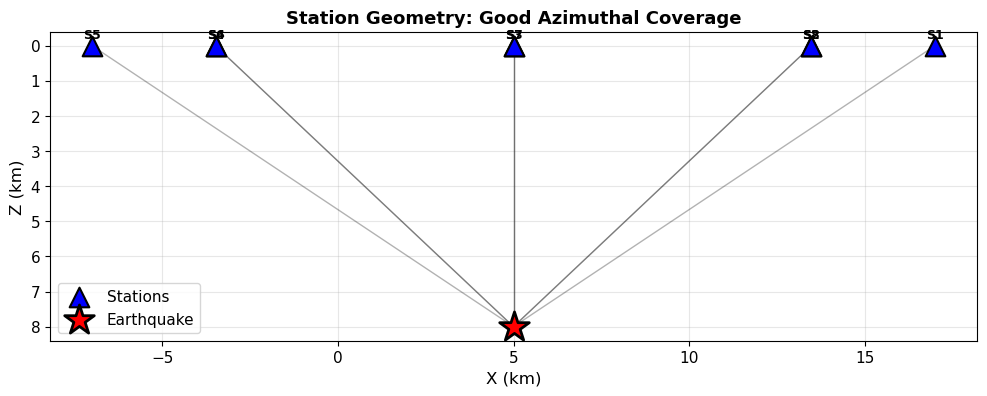


=== Geometry Metrics ===
Number of stations: 8
Azimuthal gap: 247.4°
Nearest station (DMIN): 8.00 km
Station distances: 8.00 to 14.42 km
Depth/DMIN ratio: 1.00 (< 1 suggests good depth constraint)


In [7]:
# Station geometry: circular array
n_stations = 8
radius_stations = 12.0  # km from epicenter

# Create stations in a circle around the epicenter
angles = np.linspace(0, 2*np.pi, n_stations, endpoint=False)
x_stations = x0_true + radius_stations * np.cos(angles)
z_stations = np.zeros(n_stations)  # All stations at surface

# Plot geometry
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_stations_and_source(x_stations, z_stations, x0_true, z0_true, 
                         title="Station Geometry: Good Azimuthal Coverage", ax=ax)

# Annotate stations
for i in range(n_stations):
    ax.text(x_stations[i], z_stations[i]-0.5, f'S{i+1}', 
            ha='center', va='top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Compute geometry metrics
distances = compute_distance(x0_true, z0_true, x_stations, z_stations)
gap = compute_azimuthal_gap(x0_true, z0_true, x_stations, z_stations)
dmin = np.min(distances)

print(f"\n=== Geometry Metrics ===")
print(f"Number of stations: {n_stations}")
print(f"Azimuthal gap: {gap:.1f}°")
print(f"Nearest station (DMIN): {dmin:.2f} km")
print(f"Station distances: {distances.min():.2f} to {distances.max():.2f} km")
print(f"Depth/DMIN ratio: {z0_true/dmin:.2f} (< 1 suggests good depth constraint)")

### A3. Generate synthetic arrival times (observed data)

We compute "observed" travel times using the forward model:
$$t_i^{obs} = t_0 + \frac{r_i}{v} + \epsilon_i$$

**Noise model:** We add Gaussian noise with $\sigma = 0.05$ s to simulate picking uncertainty.

In [8]:
# Generate synthetic arrival times
t_arrivals_clean = compute_travel_time_straight(x0_true, z0_true, t0_true, 
                                                 x_stations, z_stations, velocity)

# Add noise (simulating picking uncertainty)
noise_std = 0.05  # seconds (realistic for good picks)
noise = noise_std * np.random.randn(n_stations)
t_arrivals_obs = t_arrivals_clean + noise

# Display arrival times
print("=== Synthetic Arrival Times ===")
print("Station |  Distance (km) | Clean (s) | Observed (s) | Noise (s)")
print("-" * 70)
for i in range(n_stations):
    print(f"S{i+1:2d}     | {distances[i]:14.2f} | {t_arrivals_clean[i]:9.3f} | "
          f"{t_arrivals_obs[i]:12.3f} | {noise[i]:9.3f}")

print(f"\nOrigin time: {t0_true:.3f} s")
print(f"Mean travel time: {np.mean(t_arrivals_clean - t0_true):.3f} s")
print(f"Noise level: {noise_std:.3f} s (RMS)")

=== Synthetic Arrival Times ===
Station |  Distance (km) | Clean (s) | Observed (s) | Noise (s)
----------------------------------------------------------------------
S 1     |          14.42 |     4.904 |        4.929 |     0.025
S 2     |          11.66 |     4.444 |        4.437 |    -0.007
S 3     |           8.00 |     3.833 |        3.866 |     0.032
S 4     |          11.66 |     4.444 |        4.520 |     0.076
S 5     |          14.42 |     4.904 |        4.892 |    -0.012
S 6     |          11.66 |     4.444 |        4.432 |    -0.012
S 7     |           8.00 |     3.833 |        3.912 |     0.079
S 8     |          11.66 |     4.444 |        4.482 |     0.038

Origin time: 2.500 s
Mean travel time: 1.906 s
Noise level: 0.050 s (RMS)


### A4. Grid search: visualize the objective function

Before implementing iterative methods, let's **visualize the full misfit landscape** by grid search.

**Objective function (L2 norm):**
$$\phi(x_0, z_0, t_0) = \sqrt{\frac{1}{N}\sum_{i=1}^N [t_i^{obs} - t_i^{pred}(x_0, z_0, t_0)]^2}$$

We'll search over $(x, z)$ with **fixed origin time** first to see the 2D structure.

> **Prediction:** Will the misfit function have a single global minimum, or multiple local minima?

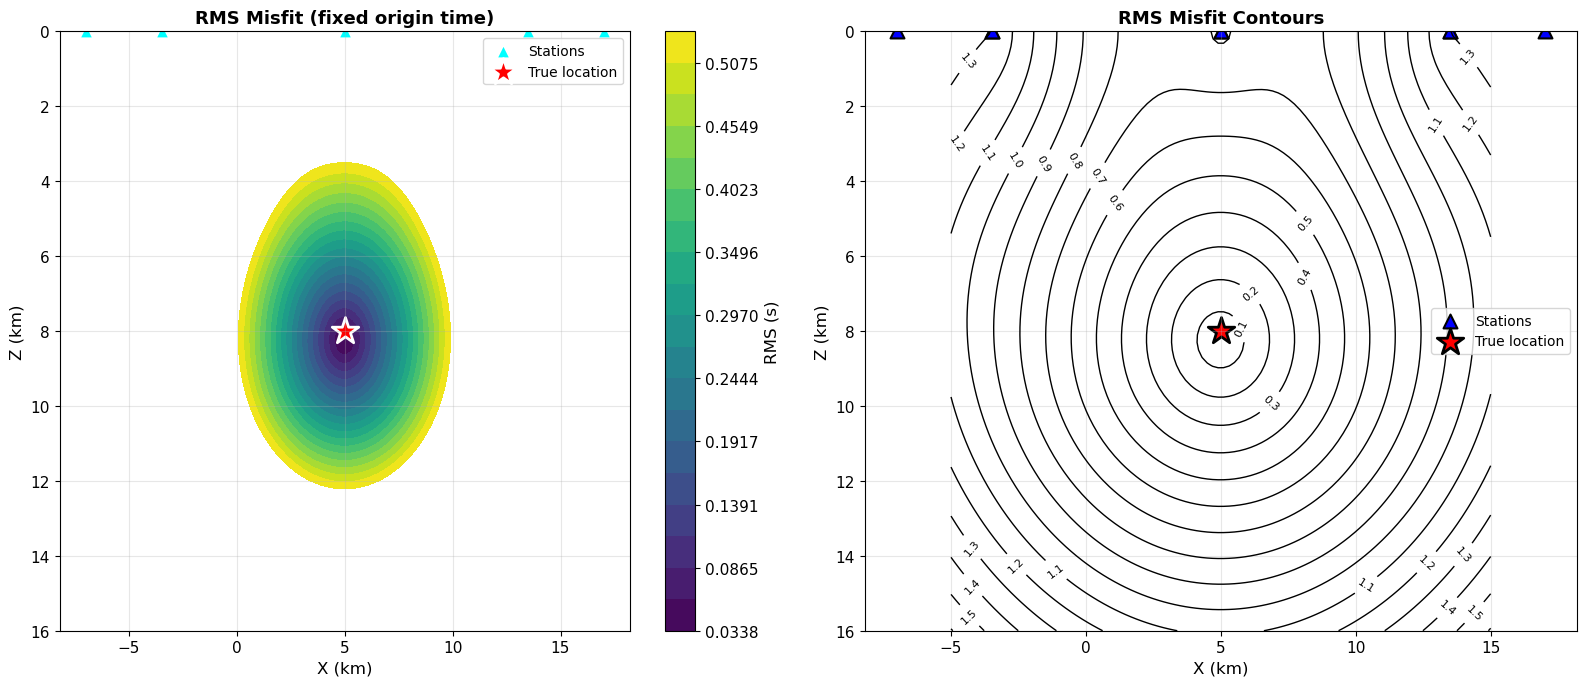

=== Grid Search Results (fixed t0) ===
Grid minimum: (4.90, 8.30) km
True location: (5.00, 8.00) km
Error: (-0.10, 0.30) km
Minimum RMS: 0.0338 s

Key Observation: Misfit surface is smooth and convex with good geometry!


In [9]:
# Grid search parameters
x_grid = np.linspace(-5, 15, 100)
z_grid = np.linspace(0, 16, 80)
X_grid, Z_grid = np.meshgrid(x_grid, z_grid)

# Compute RMS misfit at each grid point (fix t0 at true value)
RMS_grid = np.zeros_like(X_grid)

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        x_test = X_grid[i, j]
        z_test = Z_grid[i, j]
        t_pred = compute_travel_time_straight(x_test, z_test, t0_true,
                                               x_stations, z_stations, velocity)
        RMS_grid[i, j] = compute_rms_residual(t_arrivals_obs, t_pred)

# Plot misfit landscape
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: Filled contour
levels = np.linspace(RMS_grid.min(), RMS_grid.min() + 0.5, 20)
cf = axes[0].contourf(X_grid, Z_grid, RMS_grid, levels=levels, cmap='viridis')
axes[0].scatter(x_stations, z_stations, marker='^', s=100, c='cyan', 
                edgecolors='white', linewidth=1.5, label='Stations')
axes[0].scatter([x0_true], [z0_true], marker='*', s=400, c='red', 
                edgecolors='white', linewidth=2, label='True location')
axes[0].set_xlabel('X (km)', fontsize=12)
axes[0].set_ylabel('Z (km)', fontsize=12)
axes[0].set_title('RMS Misfit (fixed origin time)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(cf, ax=axes[0], label='RMS (s)')

# Panel 2: Line contours
cs = axes[1].contour(X_grid, Z_grid, RMS_grid, levels=15, colors='black', linewidths=1)
axes[1].clabel(cs, inline=True, fontsize=8)
axes[1].scatter(x_stations, z_stations, marker='^', s=100, c='blue', 
                edgecolors='k', linewidth=1.5, label='Stations')
axes[1].scatter([x0_true], [z0_true], marker='*', s=400, c='red', 
                edgecolors='k', linewidth=2, label='True location')
axes[1].set_xlabel('X (km)', fontsize=12)
axes[1].set_ylabel('Z (km)', fontsize=12)
axes[1].set_title('RMS Misfit Contours', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find minimum
min_idx = np.unravel_index(np.argmin(RMS_grid), RMS_grid.shape)
x_min = X_grid[min_idx]
z_min = Z_grid[min_idx]
rms_min = RMS_grid[min_idx]

print(f"=== Grid Search Results (fixed t0) ===")
print(f"Grid minimum: ({x_min:.2f}, {z_min:.2f}) km")
print(f"True location: ({x0_true:.2f}, {z0_true:.2f}) km")
print(f"Error: ({x_min - x0_true:.2f}, {z_min - z0_true:.2f}) km")
print(f"Minimum RMS: {rms_min:.4f} s")
print(f"\nKey Observation: Misfit surface is smooth and convex with good geometry!")

### A5. Origin time coupling: 2D slice through (x, t0)

Now fix **depth** at the true value and search over $(x, t_0)$ to see the coupling.

> **Key concept:** Changes in radial distance can be compensated by changes in origin time for distant stations.

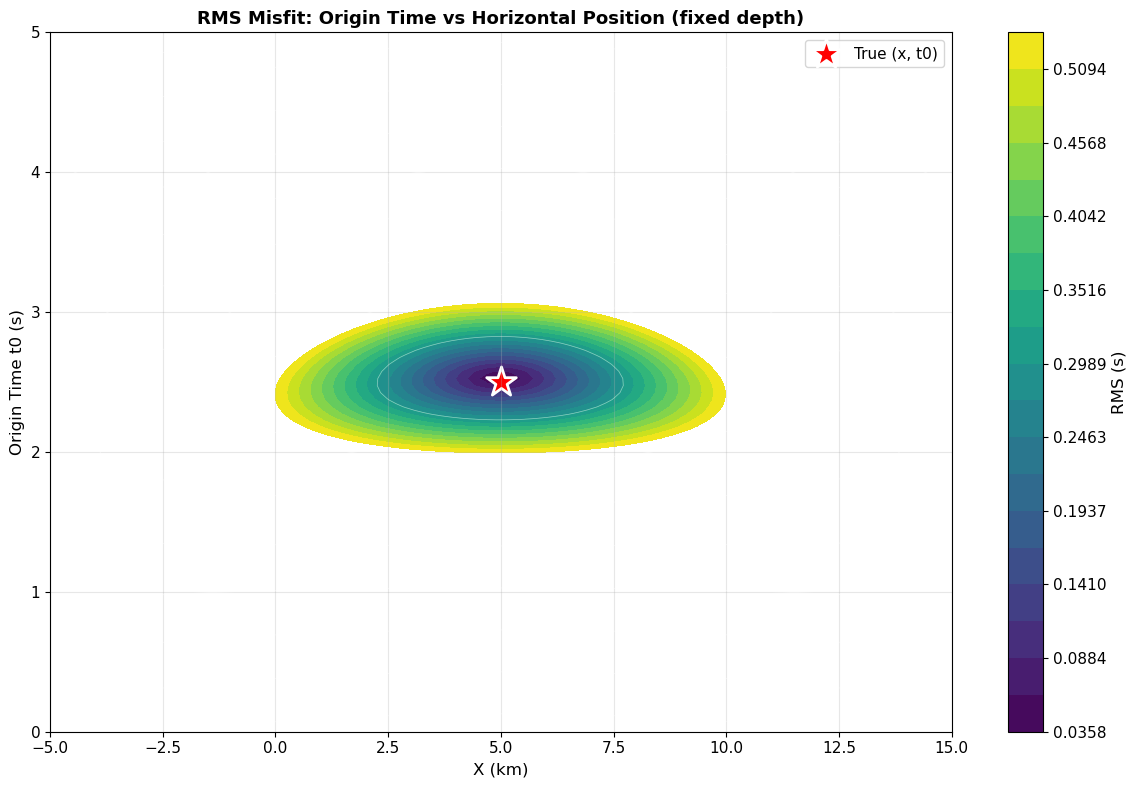

Key Observation: With good azimuthal coverage, (x, t0) are well separated.
The minimum is still well-defined (no valley/trade-off).


In [25]:
# Grid over (x, t0) with fixed depth
x_grid2 = np.linspace(-5, 15, 100)
t0_grid = np.linspace(0, 5, 100)
X_grid2, T0_grid = np.meshgrid(x_grid2, t0_grid)

# Compute RMS misfit (fix z at true value)
RMS_grid2 = np.zeros_like(X_grid2)

for i in range(X_grid2.shape[0]):
    for j in range(X_grid2.shape[1]):
        x_test = X_grid2[i, j]
        t0_test = T0_grid[i, j]
        t_pred = compute_travel_time_straight(x_test, z0_true, t0_test,
                                               x_stations, z_stations, velocity)
        RMS_grid2[i, j] = compute_rms_residual(t_arrivals_obs, t_pred)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

levels = np.linspace(RMS_grid2.min(), RMS_grid2.min() + 0.5, 20)
cf = ax.contourf(X_grid2, T0_grid, RMS_grid2, levels=levels, cmap='viridis')
cs = ax.contour(X_grid2, T0_grid, RMS_grid2, levels=10, colors='white', 
                linewidths=0.5, alpha=0.5)
ax.scatter([x0_true], [t0_true], marker='*', s=500, c='red', 
           edgecolors='white', linewidth=2, label='True (x, t0)')

ax.set_xlabel('X (km)', fontsize=12)
ax.set_ylabel('Origin Time t0 (s)', fontsize=12)
ax.set_title('RMS Misfit: Origin Time vs Horizontal Position (fixed depth)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.colorbar(cf, ax=ax, label='RMS (s)')

plt.tight_layout()
plt.show()

print("Key Observation: With good azimuthal coverage, (x, t0) are well separated.")
print("The minimum is still well-defined (no valley/trade-off).")

---

## Part B: Iterative Linearization (Geiger's Method)

Grid search is **computationally expensive** and doesn't scale to 3D + origin time.

Instead, we use **iterative linearization**:
1. Start with initial guess $\mathbf{m}^{(0)} = [x_0^{(0)}, z_0^{(0)}, t_0^{(0)}]^T$
2. Compute residuals: $\Delta t_i = t_i^{obs} - t_i^{pred}(\mathbf{m}^{(0)})$
3. Build Jacobian: $G_{ij} = \partial t_i / \partial m_j$
4. Solve linear system: $(\mathbf{G}^T\mathbf{G} + \lambda\mathbf{I})\Delta\mathbf{m} = \mathbf{G}^T\Delta\mathbf{t}$
5. Update: $\mathbf{m}^{(1)} = \mathbf{m}^{(0)} + \Delta\mathbf{m}$
6. Repeat until convergence

### B1. Implement Geiger's method

In [26]:
def locate_earthquake_geiger(x_sta, z_sta, t_obs, velocity, 
                              x0_init, z0_init, t0_init,
                              max_iter=20, damping=0.0, tol=1e-4, verbose=True):
    """
    Locate earthquake using iterative linearization (Geiger's method).
    
    Parameters:
    -----------
    x_sta, z_sta : array
        Station positions
    t_obs : array
        Observed arrival times
    velocity : float
        Constant velocity
    x0_init, z0_init, t0_init : float
        Initial guess for location and origin time
    max_iter : int
        Maximum iterations
    damping : float
        Damping parameter (lambda)
    tol : float
        Convergence tolerance (RMS change in model)
    
    Returns:
    --------
    m_final : array [x0, z0, t0]
        Final location estimate
    history : dict
        Convergence history
    """
    # Initialize
    m = np.array([x0_init, z0_init, t0_init])
    
    history = {
        'iterations': [],
        'models': [m.copy()],
        'rms': [],
        'dm_norm': []
    }
    
    for iteration in range(max_iter):
        # Extract current model
        x0, z0, t0 = m
        
        # Forward model: compute predicted arrivals
        t_pred = compute_travel_time_straight(x0, z0, t0, x_sta, z_sta, velocity)
        
        # Residuals
        dt = t_obs - t_pred
        rms = compute_rms_residual(t_obs, t_pred)
        
        # Build Jacobian
        G = compute_jacobian_straight(x0, z0, t0, x_sta, z_sta, velocity)
        
        # Solve damped least squares
        GTG = G.T @ G
        GTd = G.T @ dt
        
        if damping > 0:
            GTG += damping * np.eye(3)
        
        dm = np.linalg.solve(GTG, GTd)
        dm_norm = np.linalg.norm(dm)
        
        # Update model
        m = m + dm
        
        # Store history
        history['iterations'].append(iteration)
        history['models'].append(m.copy())
        history['rms'].append(rms)
        history['dm_norm'].append(dm_norm)
        
        if verbose:
            print(f"Iter {iteration:2d}: RMS={rms:.5f} s, "
                  f"||dm||={dm_norm:.5f}, m=[{m[0]:.3f}, {m[1]:.3f}, {m[2]:.3f}]")
        
        # Check convergence
        if dm_norm < tol:
            if verbose:
                print(f"\n✓ Converged in {iteration+1} iterations!")
            break
    else:
        if verbose:
            print(f"\n⚠ Maximum iterations ({max_iter}) reached")
    
    return m, history

print("✓ Geiger's method implementation ready")

✓ Geiger's method implementation ready


### B2. Test with reasonable initial guess

Start from a location **2 km away** from the true hypocenter.

> **Prediction:** How many iterations will it take to converge?

In [27]:
# Initial guess (near truth)
x0_init = 3.0
z0_init = 6.0
t0_init = 3.0

print(f"Initial guess: ({x0_init}, {z0_init}) km, t0 = {t0_init} s")
print(f"True location: ({x0_true}, {z0_true}) km, t0 = {t0_true} s")
print(f"Initial error: {np.sqrt((x0_init-x0_true)**2 + (z0_init-z0_true)**2):.2f} km\n")

# Run Geiger's method
m_final, history = locate_earthquake_geiger(
    x_stations, z_stations, t_arrivals_obs, velocity,
    x0_init, z0_init, t0_init,
    max_iter=20, damping=0.0, tol=1e-5, verbose=True
)

print(f"\n=== Final Result ===")
print(f"Located: ({m_final[0]:.3f}, {m_final[1]:.3f}) km, t0 = {m_final[2]:.3f} s")
print(f"True:    ({x0_true:.3f}, {z0_true:.3f}) km, t0 = {t0_true:.3f} s")
print(f"Error:   ({m_final[0]-x0_true:.3f}, {m_final[1]-z0_true:.3f}) km, "
      f"{m_final[2]-t0_true:.3f} s")
print(f"Distance error: {np.sqrt((m_final[0]-x0_true)**2 + (m_final[1]-z0_true)**2):.3f} km")

Initial guess: (3.0, 6.0) km, t0 = 3.0 s
True location: (5.0, 8.0) km, t0 = 2.5 s
Initial error: 2.83 km

Iter  0: RMS=0.36216 s, ||dm||=3.51878, m=[4.720, 9.020, 2.448]
Iter  1: RMS=0.06375 s, ||dm||=0.43541, m=[4.992, 8.680, 2.444]
Iter  2: RMS=0.02940 s, ||dm||=0.00765, m=[4.988, 8.674, 2.444]
Iter  3: RMS=0.02939 s, ||dm||=0.00007, m=[4.988, 8.674, 2.444]
Iter  4: RMS=0.02939 s, ||dm||=0.00000, m=[4.988, 8.674, 2.444]

✓ Converged in 5 iterations!

=== Final Result ===
Located: (4.988, 8.674) km, t0 = 2.444 s
True:    (5.000, 8.000) km, t0 = 2.500 s
Error:   (-0.012, 0.674) km, -0.056 s
Distance error: 0.674 km


### B3. Visualize convergence

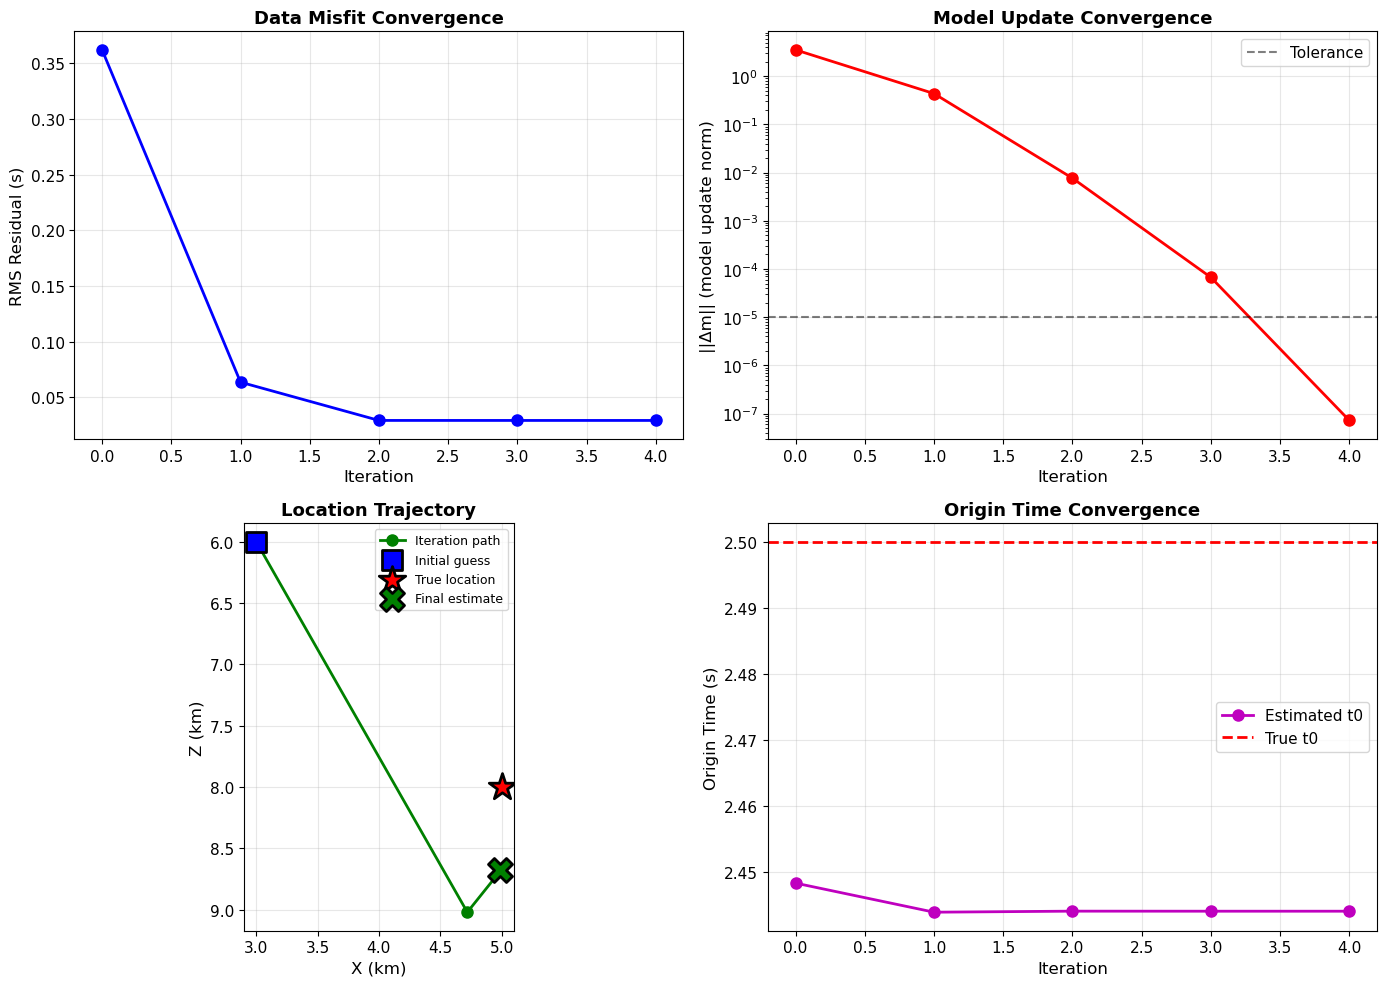

Key Observation: With good geometry, convergence is fast and stable!


In [28]:
# Plot convergence history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: RMS vs iteration
axes[0, 0].plot(history['iterations'], history['rms'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Iteration', fontsize=12)
axes[0, 0].set_ylabel('RMS Residual (s)', fontsize=12)
axes[0, 0].set_title('Data Misfit Convergence', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Model update norm
axes[0, 1].semilogy(history['iterations'], history['dm_norm'], 'ro-', linewidth=2, markersize=8)
axes[0, 1].axhline(1e-5, color='k', linestyle='--', alpha=0.5, label='Tolerance')
axes[0, 1].set_xlabel('Iteration', fontsize=12)
axes[0, 1].set_ylabel('||Δm|| (model update norm)', fontsize=12)
axes[0, 1].set_title('Model Update Convergence', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Panel 3: Location trajectory (x, z)
models_array = np.array(history['models'])
axes[1, 0].plot(models_array[:, 0], models_array[:, 1], 'go-', linewidth=2, 
                markersize=8, label='Iteration path')
axes[1, 0].scatter([x0_init], [z0_init], marker='s', s=200, c='blue', 
                   edgecolors='k', linewidth=2, label='Initial guess', zorder=10)
axes[1, 0].scatter([x0_true], [z0_true], marker='*', s=400, c='red', 
                   edgecolors='k', linewidth=2, label='True location', zorder=10)
axes[1, 0].scatter([m_final[0]], [m_final[1]], marker='X', s=300, c='green', 
                   edgecolors='k', linewidth=2, label='Final estimate', zorder=10)
axes[1, 0].set_xlabel('X (km)', fontsize=12)
axes[1, 0].set_ylabel('Z (km)', fontsize=12)
axes[1, 0].set_title('Location Trajectory', fontsize=13, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_aspect('equal')

# Panel 4: Origin time convergence
axes[1, 1].plot(history['iterations'], models_array[1:, 2], 'mo-', 
                linewidth=2, markersize=8, label='Estimated t0')
axes[1, 1].axhline(t0_true, color='r', linestyle='--', linewidth=2, label='True t0')
axes[1, 1].set_xlabel('Iteration', fontsize=12)
axes[1, 1].set_ylabel('Origin Time (s)', fontsize=12)
axes[1, 1].set_title('Origin Time Convergence', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Key Observation: With good geometry, convergence is fast and stable!")

---

## Part C: Array Geometry Effects

Now we systematically explore how **station geometry** affects location quality.

### C1. Azimuthal gap: stations on one side

**Scenario:** All 8 stations are east of the earthquake (gap = 270°).

> **Prediction:** Which direction will have the largest error: N-S, E-W, or vertical?

Azimuthal gap: 350.5°


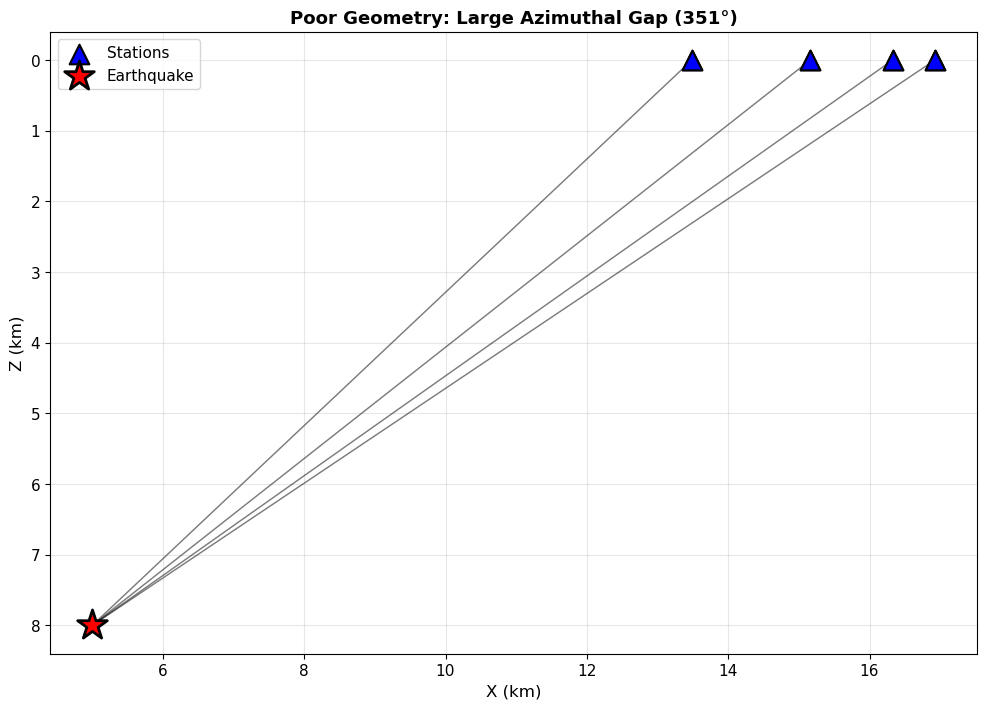


=== Locating with Large Azimuthal Gap ===
Located: (-8353386.028, 6591876.687) km, t0 = -1773505.306 s
True:    (5.000, 8.000) km, t0 = 2.500 s
Error:   (-8353391.028, 6591868.687) km

Note: Large error in X (perpendicular to array) due to poor azimuthal coverage!


In [14]:
# Create stations with large azimuthal gap (east side only)
angles_gap = np.linspace(-np.pi/4, np.pi/4, 8)  # 90° coverage on east side
x_stations_gap = x0_true + radius_stations * np.cos(angles_gap)
z_stations_gap = np.zeros(8)

# Compute metrics
gap_bad = compute_azimuthal_gap(x0_true, z0_true, x_stations_gap, z_stations_gap)
print(f"Azimuthal gap: {gap_bad:.1f}°")

# Generate arrival times
t_arrivals_gap = compute_travel_time_straight(x0_true, z0_true, t0_true,
                                               x_stations_gap, z_stations_gap, velocity)
t_arrivals_gap += noise_std * np.random.randn(8)

# Plot geometry
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_stations_and_source(x_stations_gap, z_stations_gap, x0_true, z0_true,
                         title=f"Poor Geometry: Large Azimuthal Gap ({gap_bad:.0f}°)", ax=ax)
plt.tight_layout()
plt.show()

# Locate
print("\n=== Locating with Large Azimuthal Gap ===")
m_gap, hist_gap = locate_earthquake_geiger(
    x_stations_gap, z_stations_gap, t_arrivals_gap, velocity,
    x0_init, z0_init, t0_init, verbose=False
)

print(f"Located: ({m_gap[0]:.3f}, {m_gap[1]:.3f}) km, t0 = {m_gap[2]:.3f} s")
print(f"True:    ({x0_true:.3f}, {z0_true:.3f}) km, t0 = {t0_true:.3f} s")
print(f"Error:   ({m_gap[0]-x0_true:.3f}, {m_gap[1]-z0_true:.3f}) km")
print(f"\nNote: Large error in X (perpendicular to array) due to poor azimuthal coverage!")

### C2. Error ellipsoids: quantifying uncertainty

The **posterior covariance matrix** tells us uncertainty:
$$\mathbf{C}_m = \sigma^2 (\mathbf{G}^T\mathbf{G})^{-1}$$

Eigenvalues of $\mathbf{C}_m$ give **error ellipsoid semi-axes**.

We compare **good geometry** vs **large gap**.

/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_92507/1735115494.py:27: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(eigvals[1])  # semi-minor
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_92507/1735115494.py:34: RuntimeWarning: invalid value encountered in sqrt
  ERZ = np.sqrt(Cov_m[2, 2])  # vertical error


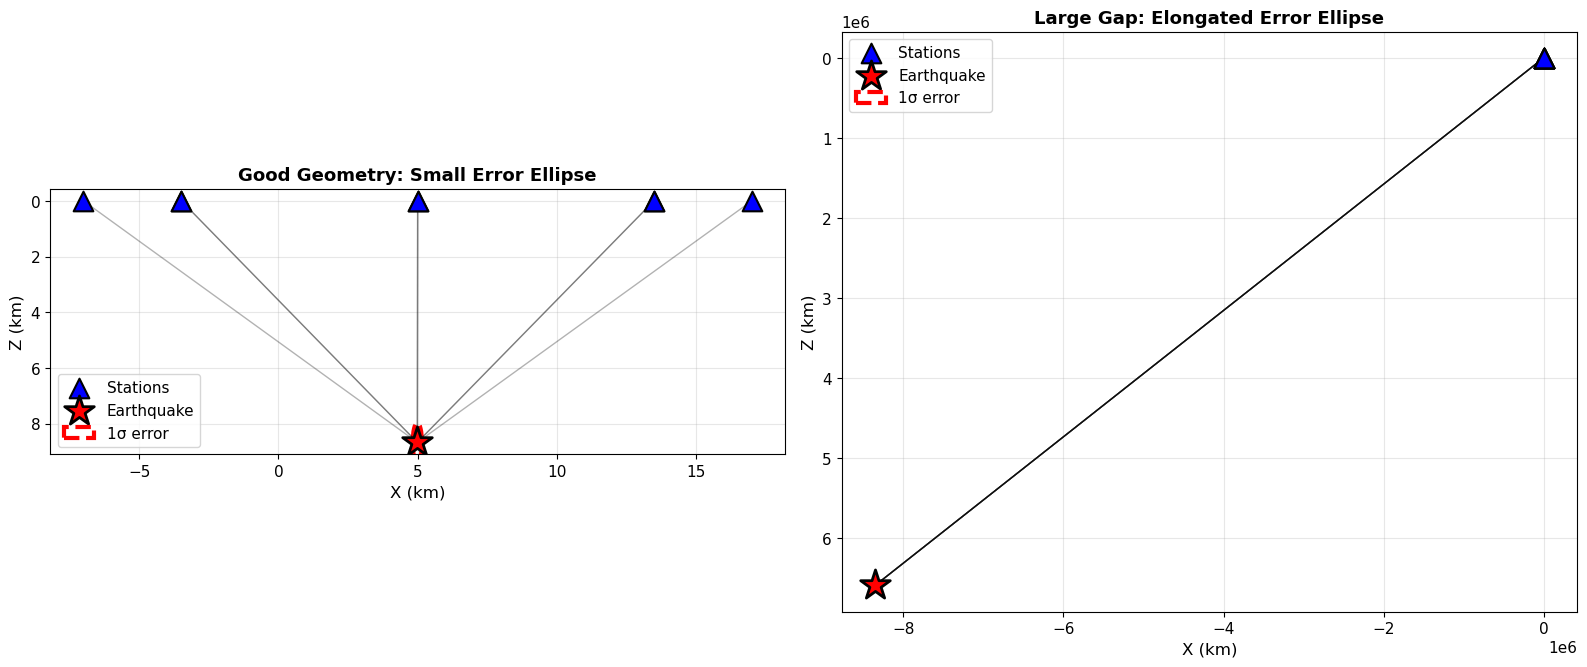

=== Error Ellipse Comparison ===
Good geometry: a=0.700 km, b=0.166 km, angle=90.0°
               ERH=0.700 km, ERZ=0.090 km

Large gap:     a=1362757.895 km, b=nan km, angle=-127.6°
               ERH=1362757.895 km, ERZ=nan km

Error increase factor: 1947181.5x in semi-major axis!

Key Observation: Gap elongates error perpendicular to array.


In [29]:
def compute_error_ellipse(x_sta, z_sta, x0, z0, t0, velocity, sigma_data):
    """
   Compute error ellipse for spatial components (x, z) from covariance.
    
    Returns semi-major axis, semi-minor axis, rotation angle
    """
    # Compute Jacobian at final location
    G = compute_jacobian_straight(x0, z0, t0, x_sta, z_sta, velocity)
    
    # Posterior covariance (spatial part only: x, z)
    GTG = G.T @ G
    Cov_m = sigma_data**2 * np.linalg.inv(GTG)
    
    # Extract spatial covariance (2x2 submatrix)
    Cov_spatial = Cov_m[:2, :2]
    
    # Eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(Cov_spatial)
    
    # Sort by eigenvalue (largest first)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    
    # Semi-axes (1-sigma)
    a = np.sqrt(eigvals[0])  # semi-major
    b = np.sqrt(eigvals[1])  # semi-minor
    
    # Rotation angle
    angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0]) * 180 / np.pi
    
    # Error metrics
    ERH = max(a, b)  # horizontal error
    ERZ = np.sqrt(Cov_m[2, 2])  # vertical error
    
    return a, b, angle, ERH, ERZ

# Compute error ellipses
a_good, b_good, ang_good, ERH_good, ERZ_good = compute_error_ellipse(
    x_stations, z_stations, m_final[0], m_final[1], m_final[2], velocity, noise_std
)

a_gap, b_gap, ang_gap, ERH_gap, ERZ_gap = compute_error_ellipse(
    x_stations_gap, z_stations_gap, m_gap[0], m_gap[1], m_gap[2], velocity, noise_std
)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Good geometry
plot_stations_and_source(x_stations, z_stations, m_final[0], m_final[1],
                         title="Good Geometry: Small Error Ellipse", ax=axes[0])
ellipse_good = Ellipse((m_final[0], m_final[1]), 2*a_good, 2*b_good, 
                       angle=ang_good, facecolor='none', edgecolor='red', 
                       linewidth=3, linestyle='--', label='1σ error')
axes[0].add_patch(ellipse_good)
axes[0].legend(fontsize=11)

# Large gap
plot_stations_and_source(x_stations_gap, z_stations_gap, m_gap[0], m_gap[1],
                         title="Large Gap: Elongated Error Ellipse", ax=axes[1])
ellipse_gap = Ellipse((m_gap[0], m_gap[1]), 2*a_gap, 2*b_gap,
                      angle=ang_gap, facecolor='none', edgecolor='red',
                      linewidth=3, linestyle='--', label='1σ error')
axes[1].add_patch(ellipse_gap)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("=== Error Ellipse Comparison ===")
print(f"Good geometry: a={a_good:.3f} km, b={b_good:.3f} km, angle={ang_good:.1f}°")
print(f"               ERH={ERH_good:.3f} km, ERZ={ERZ_good:.3f} km")
print(f"\nLarge gap:     a={a_gap:.3f} km, b={b_gap:.3f} km, angle={ang_gap:.1f}°")
print(f"               ERH={ERH_gap:.3f} km, ERZ={ERZ_gap:.3f} km")
print(f"\nError increase factor: {a_gap/a_good:.1f}x in semi-major axis!")
print(f"\nKey Observation: Gap elongates error perpendicular to array.")

### 📝 Exercise 1 (ESS 412 - Undergraduate)

**Task:** Design your own station geometry and predict the error ellipse orientation.

**Instructions:**
1. Modify the code below to create a custom station geometry (e.g., linear array, L-shape, etc.)
2. **Before running:** Sketch your prediction of where the error ellipse will be largest
3. Run the location and plot the error ellipse
4. Compare your prediction with the result

**Questions to answer:**
- How does your station pattern affect the azimuthal gap?
- Which direction has the largest uncertainty?
- How could you improve the geometry with just 1 additional station?

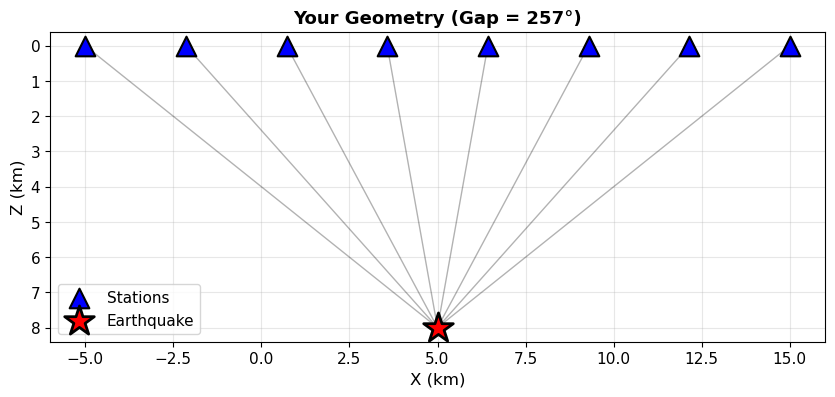

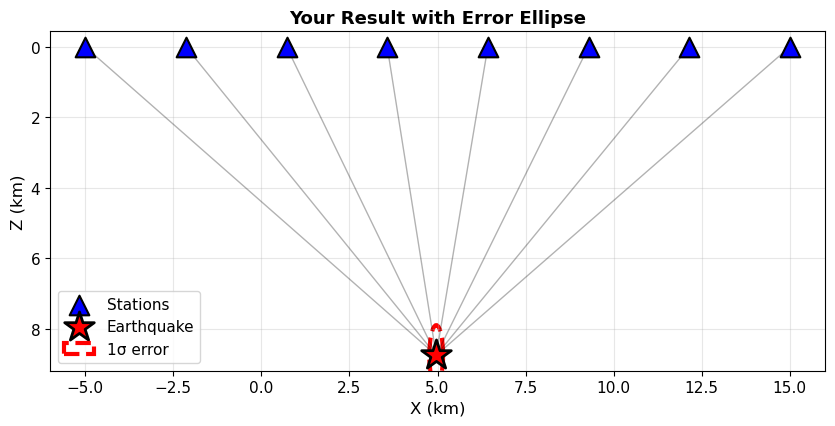

Error ellipse: a=0.854 km, b=0.195 km, angle=90.1°
ERH=0.854 km, ERZ=0.119 km

Your interpretation: [Describe what you observe]


In [16]:
# ===== YOUR CODE HERE (Exercise 1) =====

# Example: Linear array (students should modify this)
x_stations_ex1 = np.linspace(-5, 15, 8)  # Linear array in X
z_stations_ex1 = np.zeros(8)             # All at surface

# Generate data
t_arrivals_ex1 = compute_travel_time_straight(x0_true, z0_true, t0_true,
                                               x_stations_ex1, z_stations_ex1, velocity)
t_arrivals_ex1 += noise_std * np.random.randn(8)

# Plot geometry
gap_ex1 = compute_azimuthal_gap(x0_true, z0_true, x_stations_ex1, z_stations_ex1)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_stations_and_source(x_stations_ex1, z_stations_ex1, x0_true, z0_true,
                         title=f"Your Geometry (Gap = {gap_ex1:.0f}°)", ax=ax)
plt.show()

# Locate
m_ex1, _ = locate_earthquake_geiger(
    x_stations_ex1, z_stations_ex1, t_arrivals_ex1, velocity,
    x0_init, z0_init, t0_init, verbose=False
)

# Compute and plot error ellipse
a_ex1, b_ex1, ang_ex1, ERH_ex1, ERZ_ex1 = compute_error_ellipse(
    x_stations_ex1, z_stations_ex1, m_ex1[0], m_ex1[1], m_ex1[2], velocity, noise_std
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_stations_and_source(x_stations_ex1, z_stations_ex1, m_ex1[0], m_ex1[1],
                         title="Your Result with Error Ellipse", ax=ax)
ellipse_ex1 = Ellipse((m_ex1[0], m_ex1[1]), 2*a_ex1, 2*b_ex1,
                      angle=ang_ex1, facecolor='none', edgecolor='red',
                      linewidth=3, linestyle='--', label='1σ error')
ax.add_patch(ellipse_ex1)
ax.legend()
plt.show()

print(f"Error ellipse: a={a_ex1:.3f} km, b={b_ex1:.3f} km, angle={ang_ex1:.1f}°")
print(f"ERH={ERH_ex1:.3f} km, ERZ={ERZ_ex1:.3f} km")
print(f"\nYour interpretation: [Describe what you observe]")

# ===== END YOUR CODE =====

---

## Part D: The Depth Challenge

### D1. Distant stations: poor depth resolution

**Scenario:** All stations are far from the epicenter (DMIN >> depth).

> **Key concept:** Rays exit at shallow angles → depth and origin time trade off.

Distant array: DMIN = 8.00 km
Source depth: 8.00 km
Depth/DMIN ratio: 1.00 (<< 1 suggests poor depth resolution)

Takeoff angles from earthquake: 11.1° to 45.0° from horizontal
These are nearly horizontal rays → poor vertical resolution!


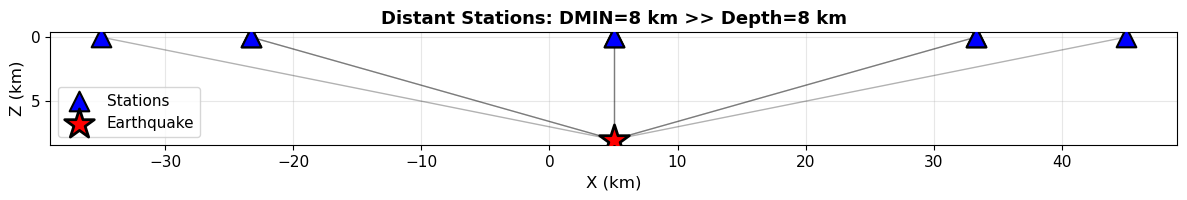

In [17]:
# Create distant circular array (radius = 40 km)
radius_far = 40.0
x_stations_far = x0_true + radius_far * np.cos(angles)
z_stations_far = np.zeros(8)

# Geometry metrics
distances_far = compute_distance(x0_true, z0_true, x_stations_far, z_stations_far)
dmin_far = np.min(distances_far)

print(f"Distant array: DMIN = {dmin_far:.2f} km")
print(f"Source depth: {z0_true:.2f} km")
print(f"Depth/DMIN ratio: {z0_true/dmin_far:.2f} (<< 1 suggests poor depth resolution)")

# Compute takeoff angles
takeoff_angles_far = np.arctan2(z0_true, distances_far) * 180 / np.pi
print(f"\nTakeoff angles from earthquake: {takeoff_angles_far.min():.1f}° to "
      f"{takeoff_angles_far.max():.1f}° from horizontal")
print("These are nearly horizontal rays → poor vertical resolution!")

# Plot geometry with ray angles
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plot_stations_and_source(x_stations_far, z_stations_far, x0_true, z0_true,
                         title=f"Distant Stations: DMIN={dmin_far:.0f} km >> Depth={z0_true:.0f} km",
                         ax=ax)
plt.tight_layout()
plt.show()

### D2. Depth/origin time trade-off with distant stations

In [18]:
# Generate arrival times for distant array
t_arrivals_far = compute_travel_time_straight(x0_true, z0_true, t0_true,
                                               x_stations_far, z_stations_far, velocity)
t_arrivals_far += noise_std * np.random.randn(8)

# Locate
print("=== Locating with Distant Stations ===")
m_far, hist_far = locate_earthquake_geiger(
    x_stations_far, z_stations_far, t_arrivals_far, velocity,
    x0_init, z0_init, t0_init, verbose=True
)

print(f"\nLocated: ({m_far[0]:.3f}, {m_far[1]:.3f}) km, t0 = {m_far[2]:.3f} s")
print(f"True:    ({x0_true:.3f}, {z0_true:.3f}) km, t0 = {t0_true:.3f} s")
print(f"Depth error: {m_far[1] - z0_true:.3f} km")

# Compute error ellipse
a_far, b_far, ang_far, ERH_far, ERZ_far = compute_error_ellipse(
    x_stations_far, z_stations_far, m_far[0], m_far[1], m_far[2], velocity, noise_std
)

print(f"\nError metrics: ERH={ERH_far:.3f} km, ERZ={ERZ_far:.3f} km")
print(f"Vertical error is {ERZ_far/ERH_far:.1f}x larger than horizontal!")
print(f"\nKey Observation: Poor depth resolution with distant stations.")

=== Locating with Distant Stations ===
Iter  0: RMS=0.47361 s, ||dm||=2.81222, m=[4.879, 8.035, 2.515]
Iter  1: RMS=0.04794 s, ||dm||=0.40395, m=[4.901, 7.632, 2.521]
Iter  2: RMS=0.03542 s, ||dm||=0.00072, m=[4.901, 7.633, 2.521]
Iter  3: RMS=0.03542 s, ||dm||=0.00000, m=[4.901, 7.633, 2.521]

✓ Converged in 4 iterations!

Located: (4.901, 7.633) km, t0 = 2.521 s
True:    (5.000, 8.000) km, t0 = 2.500 s
Depth error: -0.367 km

Error metrics: ERH=0.319 km, ERZ=0.029 km
Vertical error is 0.1x larger than horizontal!

Key Observation: Poor depth resolution with distant stations.


### D3. Grid search over depth and origin time (fixed epicenter)

Visualize the **trade-off valley** in the (depth, $t_0$) plane.

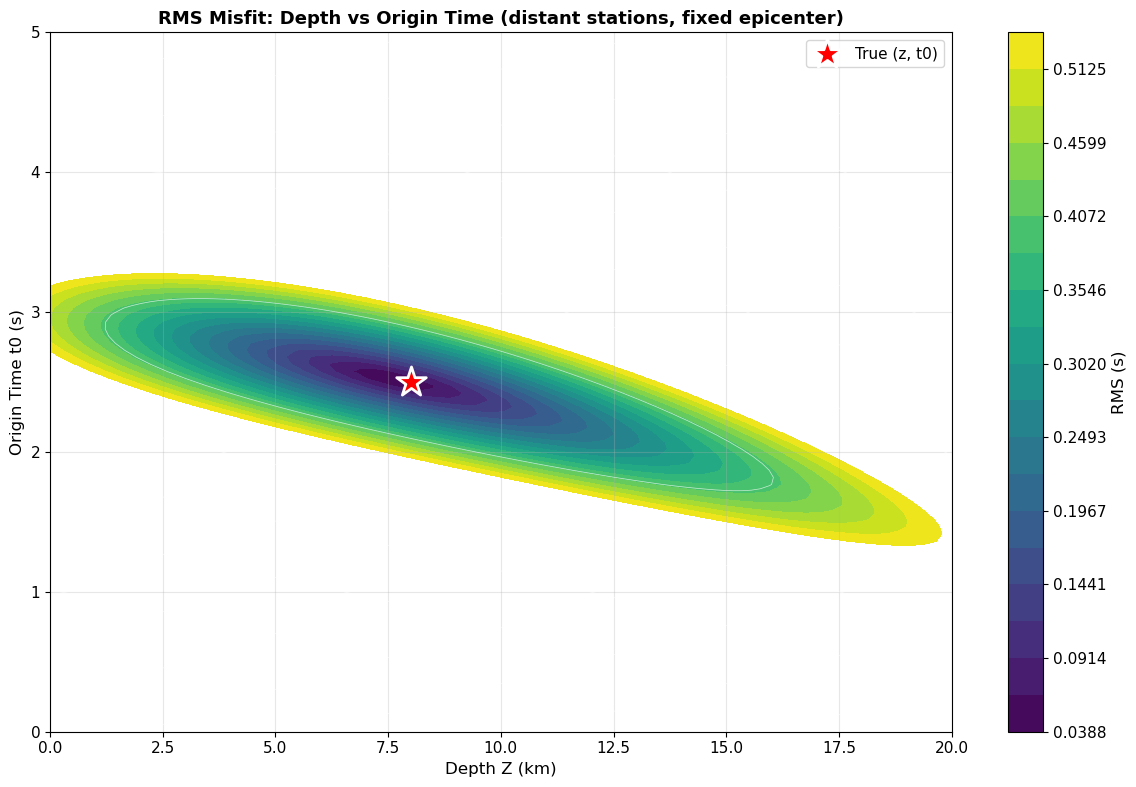

Key Observation: Notice the elongated valley in the misfit landscape!
Depth and origin time trade off when stations are far from the source.
This is why depth is often fixed in regional/local networks.


In [19]:
# Grid over (z, t0) with fixed epicenter
z_grid3 = np.linspace(0, 20, 100)
t0_grid3 = np.linspace(0, 5, 100)
Z_grid3, T0_grid3 = np.meshgrid(z_grid3, t0_grid3)

# Compute RMS for distant stations
RMS_grid3 = np.zeros_like(Z_grid3)

for i in range(Z_grid3.shape[0]):
    for j in range(Z_grid3.shape[1]):
        z_test = Z_grid3[i, j]
        t0_test = T0_grid3[i, j]
        t_pred = compute_travel_time_straight(x0_true, z_test, t0_test,
                                               x_stations_far, z_stations_far, velocity)
        RMS_grid3[i, j] = compute_rms_residual(t_arrivals_far, t_pred)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

levels = np.linspace(RMS_grid3.min(), RMS_grid3.min() + 0.5, 20)
cf = ax.contourf(Z_grid3, T0_grid3, RMS_grid3, levels=levels, cmap='viridis')
cs = ax.contour(Z_grid3, T0_grid3, RMS_grid3, levels=10, colors='white',
                linewidths=0.5, alpha=0.7)
ax.scatter([z0_true], [t0_true], marker='*', s=500, c='red',
           edgecolors='white', linewidth=2, label='True (z, t0)')

ax.set_xlabel('Depth Z (km)', fontsize=12)
ax.set_ylabel('Origin Time t0 (s)', fontsize=12)
ax.set_title('RMS Misfit: Depth vs Origin Time (distant stations, fixed epicenter)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.colorbar(cf, ax=ax, label='RMS (s)')

plt.tight_layout()
plt.show()

print("Key Observation: Notice the elongated valley in the misfit landscape!")
print("Depth and origin time trade off when stations are far from the source.")
print("This is why depth is often fixed in regional/local networks.")

### 📝 Exercise 2 (ESS 412/512 - Mixed Aperture Design)

**Task:** Design an optimal 8-station array for both epicenter AND depth resolution.

**ESS 412 (Undergraduate):**
- Create a mixed array: 4 nearby stations (radius ~12 km) + 4 distant stations (radius ~40 km)
- Compute ERH and ERZ for your design
- Compare with the all-distant array above

**ESS 512 (Graduate Extension):**
- Implement a **checkerboard test**: Create a grid of synthetic earthquakes at different depths
- Locate each event with your array
- Plot recovered depth vs true depth
- Quantify depth resolution as a function of depth and DMIN

=== Array Design Comparison ===
All distant:   ERH=0.319 km, ERZ=0.029 km, ERZ/ERH=0.09
Mixed aperture: ERH=0.354 km, ERZ=0.035 km, ERZ/ERH=0.10

Depth error improvement: 0.8x better with mixed aperture!


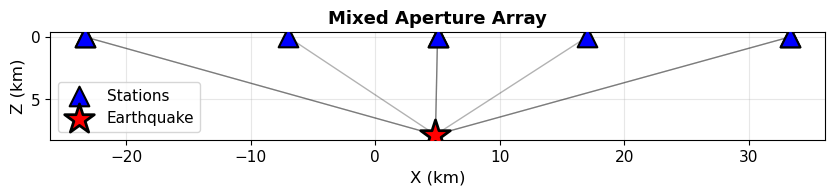

In [20]:
# ===== YOUR CODE HERE (Exercise 2 - Undergraduate) =====

# Design mixed aperture array
angles_near = np.linspace(0, 2*np.pi, 4, endpoint=False)
angles_far = np.linspace(np.pi/4, 2*np.pi + np.pi/4, 4, endpoint=False)

x_stations_mixed = np.concatenate([
    x0_true + 12.0 * np.cos(angles_near),
    x0_true + 40.0 * np.cos(angles_far)
])
z_stations_mixed = np.zeros(8)

# Test your array
t_arrivals_mixed = compute_travel_time_straight(x0_true, z0_true, t0_true,
                                                 x_stations_mixed, z_stations_mixed, velocity)
t_arrivals_mixed += noise_std * np.random.randn(8)

m_mixed, _ = locate_earthquake_geiger(
    x_stations_mixed, z_stations_mixed, t_arrivals_mixed, velocity,
    x0_init, z0_init, t0_init, verbose=False
)

a_mixed, b_mixed, ang_mixed, ERH_mixed, ERZ_mixed = compute_error_ellipse(
    x_stations_mixed, z_stations_mixed, m_mixed[0], m_mixed[1], m_mixed[2], velocity, noise_std
)

# Plot comparison
print("=== Array Design Comparison ===")
print(f"All distant:   ERH={ERH_far:.3f} km, ERZ={ERZ_far:.3f} km, ERZ/ERH={ERZ_far/ERH_far:.2f}")
print(f"Mixed aperture: ERH={ERH_mixed:.3f} km, ERZ={ERZ_mixed:.3f} km, ERZ/ERH={ERZ_mixed/ERH_mixed:.2f}")
print(f"\nDepth error improvement: {ERZ_far/ERZ_mixed:.1f}x better with mixed aperture!")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_stations_and_source(x_stations_mixed, z_stations_mixed, m_mixed[0], m_mixed[1],
                         title="Mixed Aperture Array", ax=ax)
plt.show()

# ===== END UNDERGRADUATE CODE =====

# ===== GRADUATE EXTENSION (ESS 512) =====
# Uncomment and implement:

# # Checkerboard test: grid of earthquakes at different depths
# depths_test = np.linspace(2, 15, 8)
# depth_errors = []
# 
# for z_test in depths_test:
#     # Generate arrivals for earthquake at this depth
#     t_test = compute_travel_time_straight(x0_true, z_test, t0_true,
#                                            x_stations_mixed, z_stations_mixed, velocity)
#     t_test += noise_std * np.random.randn(8)
#     
#     # Locate
#     m_test, _ = locate_earthquake_geiger(
#         x_stations_mixed, z_stations_mixed, t_test, velocity,
#         x0_init, z_test, t0_init, verbose=False
#     )
#     
#     depth_errors.append(m_test[1] - z_test)
# 
# # Plot results
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# ax1.plot(depths_test, depths_test + np.array(depth_errors), 'bo-', label='Recovered')
# ax1.plot(depths_test, depths_test, 'r--', label='True')
# ax1.set_xlabel('True Depth (km)')
# ax1.set_ylabel('Recovered Depth (km)')
# ax1.legend()
# ax1.grid(True, alpha=0.3)
# 
# ax2.plot(depths_test, depth_errors, 'ro-')
# ax2.axhline(0, color='k', linestyle='--')
# ax2.set_xlabel('True Depth (km)')
# ax2.set_ylabel('Depth Error (km)')
# ax2.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# ===== END GRADUATE CODE =====

---

## Part E: Resolution and Model Covariance

### E1. Model resolution matrix

From linear inverse theory:
$$\mathbf{R} = (\mathbf{G}^T\mathbf{G})^{-1}\mathbf{G}^T\mathbf{G} = \mathbf{I}$$
(for a well-determined problem)

**Diagonal elements** $R_{jj}$ tell us how well parameter $j$ is resolved:
- $R_{jj} = 1$: perfectly resolved
- $R_{jj} < 0.5$: poorly resolved

**Off-diagonal elements** $R_{jk}$ show trade-offs between parameters.

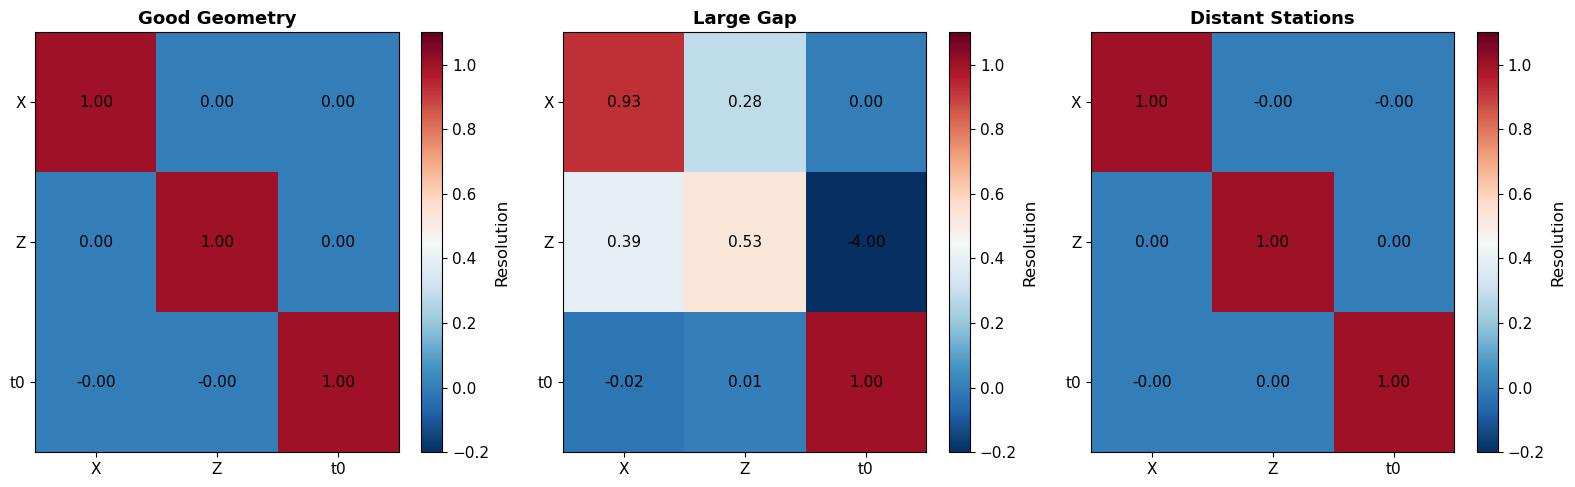

=== Resolution Matrix Diagonal Elements ===
Parameter | Good  | Gap  | Distant
----------------------------------------
X         | 1.000 | 0.927 | 1.000
Z         | 1.000 | 0.531 | 1.000
t0        | 1.000 | 1.000 | 1.000

Key Observation: Diagonal << 1 indicates poor resolution.
Off-diagonal elements show parameter trade-offs.


In [21]:
def compute_resolution_matrix(x_sta, z_sta, x0, z0, t0, velocity):
    """Compute model resolution matrix"""
    G = compute_jacobian_straight(x0, z0, t0, x_sta, z_sta, velocity)
    GTG = G.T @ G
    R = np.linalg.inv(GTG) @ GTG
    return R

# Compare resolution for different geometries
R_good = compute_resolution_matrix(x_stations, z_stations, 
                                   m_final[0], m_final[1], m_final[2], velocity)
R_gap = compute_resolution_matrix(x_stations_gap, z_stations_gap,
                                  m_gap[0], m_gap[1], m_gap[2], velocity)
R_far = compute_resolution_matrix(x_stations_far, z_stations_far,
                                  m_far[0], m_far[1], m_far[2], velocity)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
param_names = ['X', 'Z', 't0']

for i, (R, title) in enumerate([(R_good, 'Good Geometry'),
                                 (R_gap, 'Large Gap'),
                                 (R_far, 'Distant Stations')]):
    im = axes[i].imshow(R, cmap='RdBu_r', vmin=-0.2, vmax=1.1, aspect='auto')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xticks(range(3))
    axes[i].set_yticks(range(3))
    axes[i].set_xticklabels(param_names)
    axes[i].set_yticklabels(param_names)
    
    # Annotate values
    for row in range(3):
        for col in range(3):
            text = axes[i].text(col, row, f'{R[row, col]:.2f}',
                              ha="center", va="center", color="black", fontsize=11)
    
    plt.colorbar(im, ax=axes[i], label='Resolution')

plt.tight_layout()
plt.show()

print("=== Resolution Matrix Diagonal Elements ===")
print("Parameter | Good  | Gap  | Distant")
print("-" * 40)
for i, name in enumerate(['X', 'Z', 't0']):
    print(f"{name:9s} | {R_good[i,i]:.3f} | {R_gap[i,i]:.3f} | {R_far[i,i]:.3f}")

print("\nKey Observation: Diagonal << 1 indicates poor resolution.")
print("Off-diagonal elements show parameter trade-offs.")

---

## Part F: Failure Modes and Diagnostics

### F1. Bad initial guess: convergence to local minimum?

**Test:** Start far from the true location and see if Geiger's method converges.

> **Prediction:** Will the method converge if we start 20 km away?

In [22]:
# Very bad initial guess
x0_bad = -10.0
z0_bad = 20.0
t0_bad = 5.0

print(f"Bad initial guess: ({x0_bad}, {z0_bad}) km, t0 = {t0_bad} s")
print(f"Distance from true: {np.sqrt((x0_bad-x0_true)**2 + (z0_bad-z0_true)**2):.1f} km\n")

# Try to locate
m_bad, hist_bad = locate_earthquake_geiger(
    x_stations, z_stations, t_arrivals_obs, velocity,
    x0_bad, z0_bad, t0_bad,
    max_iter=30, verbose=True
)

print(f"\nFinal: ({m_bad[0]:.3f}, {m_bad[1]:.3f}) km, t0 = {m_bad[2]:.3f} s")
print(f"True:  ({x0_true:.3f}, {z0_true:.3f}) km, t0 = {t0_true:.3f} s")
print(f"\nKey Observation: With good geometry, even bad initial guesses converge!")
print("The misfit surface is convex (no local minima).")

Bad initial guess: (-10.0, 20.0) km, t0 = 5.0 s
Distance from true: 19.2 km

Iter  0: RMS=4.96270 s, ||dm||=34.53277, m=[20.880, 4.542, 4.927]
Iter  1: RMS=3.56252 s, ||dm||=82.20511, m=[68.906, 69.679, -9.510]
Iter  2: RMS=2.10863 s, ||dm||=1154.91805, m=[-758.200, -714.351, 177.647]
Iter  3: RMS=347.44395 s, ||dm||=198297.73500, m=[142839.872, 132179.678, 32438.493]
Iter  4: RMS=64869.15204 s, ||dm||=7143603.76943, m=[-5177306.430, -4503918.249, 1143165.350]
Iter  5: RMS=2286861.45506 s, ||dm||=625981904.83243, m=[-465502843.318, -415480901.229, -103983732.857]
Iter  6: RMS=8420.67786 s, ||dm||=545769399.68218, m=[-286086569.154, -929742418.928, -138756273.874]
Iter  7: RMS=23370771.79215 s, ||dm||=386903697.45492, m=[100620181.843, -940460014.246, -144879425.746]
Iter  8: RMS=12758468.74463 s, ||dm||=73802769.90574, m=[28554675.085, -949643829.332, -157882084.012]
Iter  9: RMS=463417.38184 s, ||dm||=30097138.96517, m=[-1450411.754, -951893145.724, -158569916.436]
Iter 10: RMS=79120.

### F2. Wrong velocity model: systematic bias

**Scenario:** We use $v = 6.5$ km/s to locate, but true velocity is $v = 6.0$ km/s (8% error).

> **Prediction:** Will the recovered depth be too shallow or too deep?

In [23]:
# Wrong velocity model (too fast)
v_wrong = 6.5  # km/s (true is 6.0)

print(f"Using wrong velocity: {v_wrong} km/s (true: {velocity} km/s)")
print(f"Velocity error: {100*(v_wrong - velocity)/velocity:.1f}%\n")

# Locate with wrong velocity
m_wrong, _ = locate_earthquake_geiger(
    x_stations, z_stations, t_arrivals_obs, v_wrong,
    x0_init, z0_init, t0_init, verbose=False
)

print(f"Located (wrong v): ({m_wrong[0]:.3f}, {m_wrong[1]:.3f}) km, t0 = {m_wrong[2]:.3f} s")
print(f"True location:     ({x0_true:.3f}, {z0_true:.3f}) km, t0 = {t0_true:.3f} s")
print(f"\nDepth bias: {m_wrong[1] - z0_true:.3f} km ({100*(m_wrong[1]-z0_true)/z0_true:.1f}%)")
print(f"Origin time bias: {m_wrong[2] - t0_true:.3f} s")
print(f"\nKey Observation: Too-fast velocity → event located too SHALLOW.")
print("This is because fast velocity predicts shorter travel times,")
print("so the algorithm compensates by reducing depth (shorter ray path).")

Using wrong velocity: 6.5 km/s (true: 6.0 km/s)
Velocity error: 8.3%

Located (wrong v): (4.989, 7.574) km, t0 = 2.722 s
True location:     (5.000, 8.000) km, t0 = 2.500 s

Depth bias: -0.426 km (-5.3%)
Origin time bias: 0.222 s

Key Observation: Too-fast velocity → event located too SHALLOW.
This is because fast velocity predicts shorter travel times,
so the algorithm compensates by reducing depth (shorter ray path).


### 📝 Exercise 3 (ESS 512 - Graduate Only)

**Task:** Implement iterative location with **curved rays** using depth-dependent velocity.

**Background:** We've used straight rays ($v = const$) so far. In reality:
- Velocity increases with depth: $v(z) = v_0 + kz$
- Rays curve (bend toward faster material)
- Straight-ray Jacobian is approximate

**Your task:**
1. Define a velocity gradient model: $v(z) = 6.0 + 0.1z$ km/s
2. Use PyKonal (or eikonalsolver) to compute travel times through this model
3. Implement a ray tracer to get ray paths
4. Build a curved-ray Jacobian by finite differences: $G_{ij} \approx [t_i(m_j + \delta m_j) - t_i(m_j)]/\delta m_j$
5. Iterate: re-trace rays at each iteration
6. Compare straight-ray vs curved-ray solutions

**Hint:** Follow the pattern from the tomography notebook ([travel_time_tomography_iterative_pykonal.ipynb](../notebooks/travel_time_tomography_iterative_pykonal.ipynb)).

In [24]:
# ===== GRADUATE EXERCISE 3 (ESS 512) =====
# Uncomment and implement:

# # You'll need PyKonal: pip install pykonal
# try:
#     import pykonal
# except ImportError:
#     print("Installing pykonal...")
#     import subprocess
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "pykonal"])
#     import pykonal
# 
# # Define velocity model
# nx_pk, nz_pk = 201, 201
# x_pk = np.linspace(-20, 30, nx_pk)
# z_pk = np.linspace(0, 25, nz_pk)
# X_pk, Z_pk = np.meshgrid(x_pk, z_pk, indexing='ij')
# 
# # Velocity gradient: v(z) = 6.0 + 0.1*z
# v_pk = 6.0 + 0.1 * Z_pk
# 
# # Implement iterative location with curved rays
# # [Your code here]
# 
# # Compare with straight-ray solution
# # [Your code here]

# ===== END GRADUATE EXERCISE =====

---

## Wrap-up: What you should be able to explain (verbally)

After completing this notebook, you should be able to answer:

**Conceptual:**
1. Why is earthquake location a **nonlinear** inverse problem?
2. What are the 4 model parameters in earthquake location?
3. How does azimuthal gap affect error ellipse shape?
4. Why is depth the hardest parameter to constrain?
5. What is the difference between ERH and ERZ?

**Mathematical:**
6. Write the forward model: $t_i = f(\mathbf{m})$
7. What is in the Jacobian matrix $\mathbf{G}$ for straight rays?
8. Why do we need damping in the least squares solution?
9. How does the resolution matrix diagnose parameter trade-offs?

**Practical:**
10. Given a new earthquake with large azimuthal gap (200°), what can you say about location uncertainty?
11. If you can only add ONE more station to a poorly-constrained network, where should you put it?
12. How would you diagnose that your velocity model is biased (too fast or too slow)?

---

## Summary and connections

### Key Takeaways

**Location is the dual of tomography:**
- Tomography: known sources → solve for $v(\mathbf{x})$
- Location: known $v(\mathbf{x})$ → solve for source $\mathbf{x}_0, t_0$

**Geometry matters more than number of stations:**
- Small azimuthal gap → good horizontal constraint
- Wide aperture (nearby stations) → good depth constraint
- DMIN << depth → depth and $t_0$ decouple

**Depth is special:**
- Requires steep takeoff angles (nearby stations)
- Trades off with origin time for distant arrays
- Very sensitive to velocity model errors

**Iterative linearization works:**
- Geiger's method converges rapidly with reasonable initial guess
- Misfit surface is convex for good geometry (no local minima)
- Damping helps stabilize poorly-conditioned problems

### Connections to Other Modules

**Module 3 (Ray Theory):**
- Takeoff angles determine depth sensitivity
- Ray parameter $p$ connects to horizontal slowness
- Curved rays in layered media affect depth estimates

**Module 5 (Tomography):**
- Same inverse framework: $\mathbf{G}$, damping, resolution
- Location has fewer unknowns but tighter geometric constraints
- Joint location-tomography solves both simultaneously

**Module 6 (Source Mechanisms):**
- Accurate locations prerequisite for moment tensor inversion
- Location errors propagate into mechanism errors
- Relative locations (double-difference) improve mechanism resolution

### Further Reading

**Classic methods:**
- Geiger, L. (1912). Probability method for the determination of earthquake epicenters. *Bull. St. Louis Univ.*, 8, 60-71.
- Lee, W. H. K., & Stewart, S. W. (1981). *Principles and Applications of Microearthquake Networks*. Academic Press.

**Modern algorithms:**
- Lomax, A., et al. (2000). NonLinLoc: Probabilistic earthquake location in 3D models. *Advances in Seismic Event Location*, 101-134.
- Waldhauser, F., & Ellsworth, W. L. (2000). Double-difference earthquake location. *BSSA*, 90(6), 1353-1368.

**Review:**
- Husen, S., & Hardebeck, J. L. (2010). Earthquake location accuracy. *CORSSA*. doi:10.5078/corssa-55815573
